Starting Training on cuda...
Epoch 1/50 | T_Loss: 0.4444 | V_Dice: 0.0000
Epoch 2/50 | T_Loss: 0.3696 | V_Dice: 0.0000
Epoch 3/50 | T_Loss: 0.3591 | V_Dice: 0.0000
Epoch 4/50 | T_Loss: 0.3451 | V_Dice: 0.0000
Epoch 5/50 | T_Loss: 0.3466 | V_Dice: 0.3723
Epoch 6/50 | T_Loss: 0.3359 | V_Dice: 0.2523
Epoch 7/50 | T_Loss: 0.3339 | V_Dice: 0.4001
Epoch 8/50 | T_Loss: 0.3315 | V_Dice: 0.3946
Epoch 9/50 | T_Loss: 0.3270 | V_Dice: 0.3431
Epoch 10/50 | T_Loss: 0.3260 | V_Dice: 0.3573
Epoch 11/50 | T_Loss: 0.3179 | V_Dice: 0.2771
Epoch 12/50 | T_Loss: 0.3140 | V_Dice: 0.4025
Epoch 13/50 | T_Loss: 0.3017 | V_Dice: 0.4870
Epoch 14/50 | T_Loss: 0.2915 | V_Dice: 0.4797
Epoch 15/50 | T_Loss: 0.2753 | V_Dice: 0.5718
Epoch 16/50 | T_Loss: 0.2564 | V_Dice: 0.4898
Epoch 17/50 | T_Loss: 0.2337 | V_Dice: 0.6054
Epoch 18/50 | T_Loss: 0.2173 | V_Dice: 0.6503
Epoch 19/50 | T_Loss: 0.2030 | V_Dice: 0.6213
Epoch 20/50 | T_Loss: 0.1932 | V_Dice: 0.6722
Epoch 21/50 | T_Loss: 0.1765 | V_Dice: 0.6622
Epoch 22/50 | 

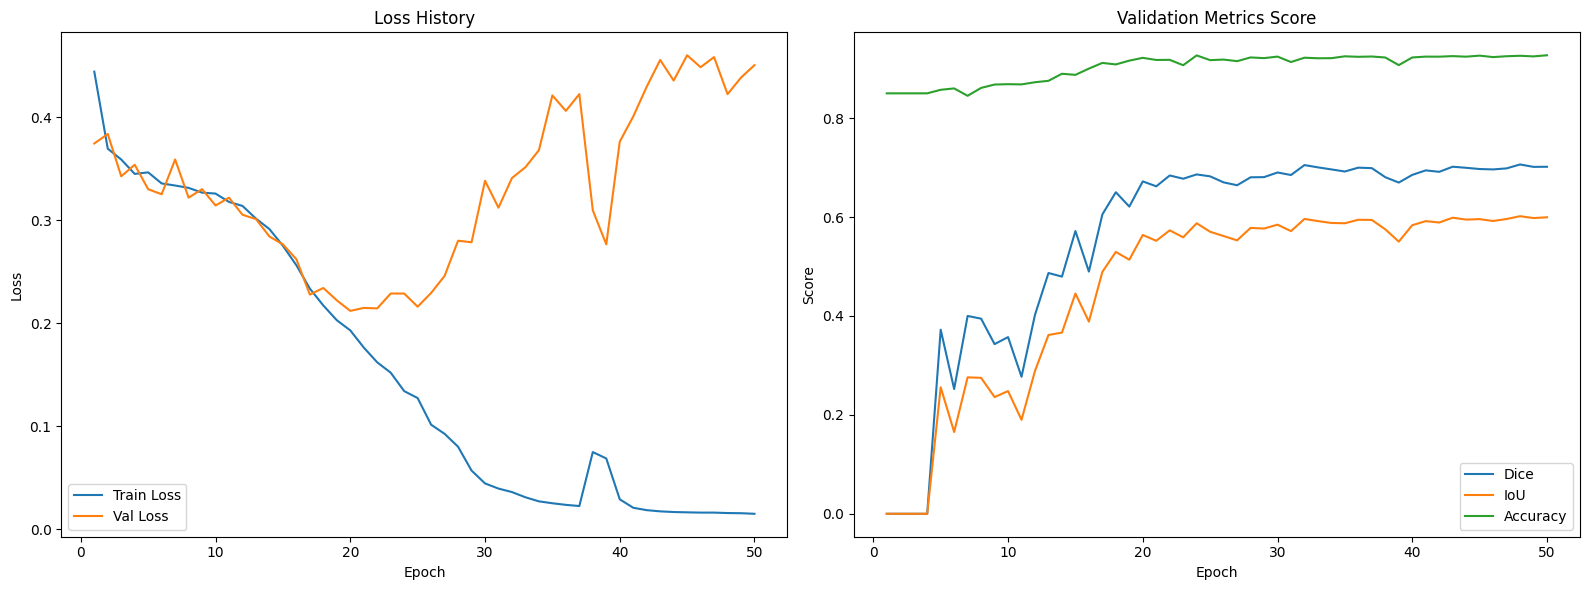

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from glob import glob
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# ==========================================
# 1. DATASET CLASS (Updated for Extension Flexibility)
# ==========================================
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        # Flexible extension handling for Kvasir-SEG (.jpg images, .png masks)
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.[jJ][pP][gG]")))
        self.mask_paths = sorted(glob(os.path.join(mask_dir, "*.[pP][nN][gG]")) + 
                                 glob(os.path.join(mask_dir, "*.[jJ][pP][gG]")))
        self.transform = transform
        
        if len(self.image_paths) == 0 or len(self.mask_paths) == 0:
            raise RuntimeError(f"Found 0 files. Images: {len(self.image_paths)}, Masks: {len(self.mask_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256))

        image = image.transpose((2, 0, 1)) / 255.0  # CHW
        mask = mask[np.newaxis, ...] / 255.0       # CHW

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

# ==========================================
# 2. MODEL ARCHITECTURE (Untouched)
# ==========================================
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def CBR(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = CBR(3, 64)
        self.enc2 = CBR(64, 128)
        self.enc3 = CBR(128, 256)
        self.enc4 = CBR(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = CBR(512, 1024)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = CBR(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = CBR(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = CBR(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = CBR(128, 64)
        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.upconv4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        d3 = self.upconv3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.upconv2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.upconv1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return torch.sigmoid(self.final(d1))

# ==========================================
# 3. METRIC CALCULATION HELPER
# ==========================================
def calculate_metrics(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    target = (target > 0.5).float()
    
    tp = (pred * target).sum().item()
    fp = (pred * (1 - target)).sum().item()
    fn = ((1 - pred) * target).sum().item()
    tn = ((1 - pred) * (1 - target)).sum().item()
    
    eps = 1e-7
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    dice = 2 * tp / (2 * tp + fp + fn + eps)
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    
    return {
        "accuracy": accuracy, "precision": precision, "recall": recall,
        "f1": f1, "iou": iou, "dice": dice
    }

# ==========================================
# 4. MAIN TRAINING LOOP
# ==========================================
def train_and_evaluate():
    # Paths
    image_dir = r'D:\Biose\Train\Final_Code\Dataset\image'
    mask_dir = r'D:\Biose\Train\Final_Code\Dataset\label'

    # Hyperparameters
    batch_size = 4
    lr = 1e-4
    epochs = 50
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Data Setup
    full_dataset = SegmentationDataset(image_dir, mask_dir)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

    # Model Initialization
    model = UNet().to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    print(f"Starting Training on {device}...")

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss = 0
        train_m = {"accuracy": 0, "precision": 0, "recall": 0, "f1": 0, "iou": 0, "dice": 0}

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            metrics = calculate_metrics(outputs, masks)
            for k in train_m: train_m[k] += metrics[k]

        # Validation Phase
        model.eval()
        val_loss = 0
        val_m = {"accuracy": 0, "precision": 0, "recall": 0, "f1": 0, "iou": 0, "dice": 0}

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                metrics = calculate_metrics(outputs, masks)
                for k in val_m: val_m[k] += metrics[k]

        # Averaging
        n_t, n_v = len(train_loader), len(val_loader)
        epoch_data = {
            "epoch": epoch + 1,
            "train_loss": train_loss / n_t,
            "val_loss": val_loss / n_v,
            **{f"train_{k}": v / n_t for k, v in train_m.items()},
            **{f"val_{k}": v / n_v for k, v in val_m.items()}
        }
        history.append(epoch_data)

        print(f"Epoch {epoch+1}/{epochs} | T_Loss: {epoch_data['train_loss']:.4f} | V_Dice: {epoch_data['val_dice']:.4f}")

    # Save to CSV
    df = pd.DataFrame(history)
    df.to_csv("training_metrics_results.csv", index=False)
    print("Metrics saved to training_metrics_results.csv")
    
    # Save Model
    torch.save(model.state_dict(), "final_unet_model.pth")
    
    return df

# ==========================================
# 5. PLOTTING FUNCTION
# ==========================================
def plot_results(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot Loss
    ax1.plot(df['epoch'], df['train_loss'], label='Train Loss')
    ax1.plot(df['epoch'], df['val_loss'], label='Val Loss')
    ax1.set_title('Loss History')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot Metrics (Validation)
    ax2.plot(df['epoch'], df['val_dice'], label='Dice')
    ax2.plot(df['epoch'], df['val_iou'], label='IoU')
    ax2.plot(df['epoch'], df['val_accuracy'], label='Accuracy')
    ax2.set_title('Validation Metrics Score')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Score')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('training_plots.png')
    plt.show()

# Run the process
if __name__ == "__main__":
    results_df = train_and_evaluate()
    plot_results(results_df)